In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Scikit-learn — data splitting, encoding, metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)

# TensorFlow / Keras — deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional,
                                      LSTM, Dense, Dropout,
                                      SpatialDropout1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,
                                         ReduceLROnPlateau,
                                         ModelCheckpoint)

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  STEP 2: LOAD THE DATASET
#
#  The dataset URL directly points to a CSV file on HuggingFace.
#  pandas can read CSV files directly from URLs — no download needed.
#
#  URL: https://huggingface.co/datasets/ahmedheakl/
#       resume-atlas/resolve/main/train.csv
# ═══════════════════════════════════════════════════════════════

URL = "https://huggingface.co/datasets/ahmedheakl/resume-atlas/resolve/main/train.csv"

print("Loading dataset from HuggingFace...")
df = pd.read_csv(URL)
# pd.read_csv() can read directly from a URL — no local file needed
# It downloads, parses the CSV, and returns a DataFrame (table)

print(f"✅ Dataset loaded successfully!")
print(f"\nShape   : {df.shape}")
# Expected: (13389, 2)
# 13389 rows = 13389 resumes
# 2 columns = 'Category' and 'Text'

print(f"\nColumns : {df.columns.tolist()}")
# Expected: ['Category', 'Text']

print(f"\nData types:\n{df.dtypes}")
# Both should be 'object' (string type in pandas)

print(f"\nFirst 3 rows:\n{df.head(5)}")
# Shows actual resume content and their categories

Loading dataset from HuggingFace...
✅ Dataset loaded successfully!

Shape   : (13389, 2)

Columns : ['Category', 'Text']

Data types:
Category    object
Text        object
dtype: object

First 3 rows:
     Category                                               Text
0  Accountant  education omba executive leadership university...
1  Accountant  howard gerrard accountant deyjobcom birmingham...
2  Accountant  kevin frank senior accountant inforesumekraftc...
3  Accountant  place birth nationality olivia ogilvy accounta...
4  Accountant  stephen greet cpa senior accountant 9 year exp...


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
#
#  EDA answers 6 critical questions:
#  Q1. How many categories are there?
#  Q2. How balanced are the categories?
#  Q3. Are there missing values?
#  Q4. How long are the resumes? (sets MAX_LEN)
#  Q5. Is the text real or synthetic? (learned the hard way!)
#  Q6. What does the text actually look like?
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ── Q1: How many categories? ──────────────────────────────────
num_categories = df['Category'].nunique()
print(f"\nQ1. Total categories : {num_categories}")
print(f"    Category names   :")
for i, cat in enumerate(sorted(df['Category'].unique())):
    print(f"    {i+1:>2}. {cat}")

# ── Q2: Category distribution — reveals class imbalance ───────
print(f"\nQ2. Category distribution (sorted by count):")
cat_counts = df['Category'].value_counts()
print(cat_counts.to_string())
print(f"\n    Most common  : {cat_counts.index[0]}"
      f" ({cat_counts.iloc[0]} resumes)")
print(f"    Least common : {cat_counts.index[-1]}"
      f" ({cat_counts.iloc[-1]} resumes)")
print(f"    Imbalance    : {cat_counts.iloc[0]/cat_counts.iloc[-1]:.1f}x")

# ── Q3: Missing values ────────────────────────────────────────
print(f"\nQ3. Missing values:")
print(df.isnull().sum())
# If any NaN → must handle before training

# ── Q4: Resume length — critical for setting MAX_LEN ──────────
df['word_count'] = df['Text'].fillna('').apply(
    lambda x: len(str(x).split())
)
print(f"\nQ4. Resume word count statistics:")
print(df['word_count'].describe().round(1))
p50  = int(df['word_count'].quantile(0.50))
p85  = int(df['word_count'].quantile(0.85))
p95  = int(df['word_count'].quantile(0.95))
print(f"\n    50th percentile : {p50} words")
print(f"    85th percentile : {p85} words  ← we use this as MAX_LEN")
print(f"    95th percentile : {p95} words")
# WHY 85th? Captures most content without wasting memory on outliers

# ── Q5: Is text real or synthetic? ────────────────────────────
unique_ratio = df['Text'].nunique() / len(df)
print(f"\nQ5. Text uniqueness ratio : {unique_ratio:.2%}")
if unique_ratio > 0.8:
    print("Text is REAL — suitable for NLP/LSTM")
else:
    print("Text may be SYNTHETIC — LSTM will fail!")
# We learned this lesson from the fake synthetic dataset (50% accuracy!)

# ── Q6: Sample text from 2 different categories ───────────────
print(f"\nQ6. Sample resume text (first 200 chars):")
print(f"\n--- Accountant ---")
print(df[df['Category']=='Accountant']['Text'].iloc[0][:200])
print(f"\n--- Information-Technology ---")
it_sample = df[df['Category'].str.contains('IT|Tech|Software',
               case=False, na=False)]
if len(it_sample) > 0:
    print(it_sample['Text'].iloc[0][:200])


EXPLORATORY DATA ANALYSIS

Q1. Total categories : 43
    Category names   :
     1. Accountant
     2. Advocate
     3. Agriculture
     4. Apparel
     5. Architecture
     6. Arts
     7. Automobile
     8. Aviation
     9. BPO
    10. Banking
    11. Blockchain
    12. Building and Construction
    13. Business Analyst
    14. Civil Engineer
    15. Consultant
    16. Data Science
    17. Database
    18. Designing
    19. DevOps
    20. Digital Media
    21. DotNet Developer
    22. ETL Developer
    23. Education
    24. Electrical Engineering
    25. Finance
    26. Food and Beverages
    27. Health and Fitness
    28. Human Resources
    29. Information Technology
    30. Java Developer
    31. Management
    32. Mechanical Engineer
    33. Network Security Engineer
    34. Operations Manager
    35. PMO
    36. Public Relations
    37. Python Developer
    38. React Developer
    39. SAP Developer
    40. SQL Developer
    41. Sales
    42. Testing
    43. Web Designing

Q2. Ca

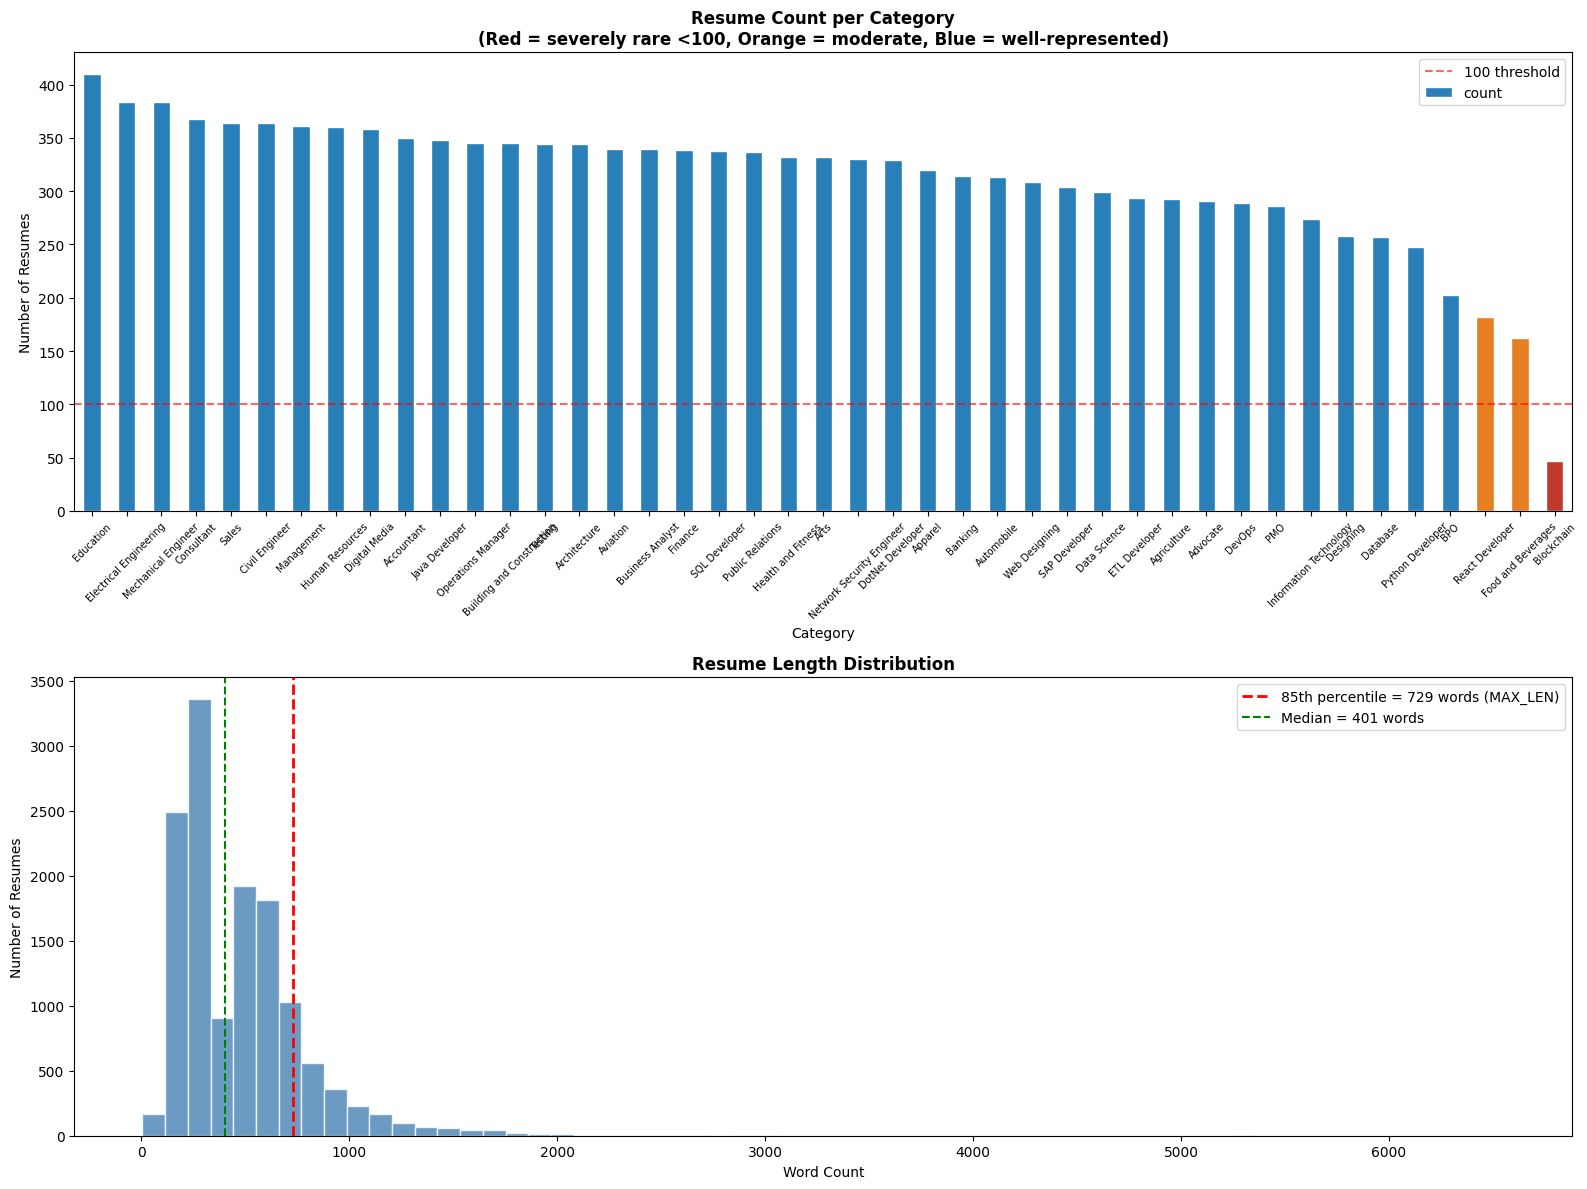


EDA complete. Setting MAX_LEN = 729


In [ ]:
# ──────────────────────────────────────────────────────────────
# VISUALISATION 1: Category distribution
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Bar chart: resume count per category
colors = ['#c0392b' if c < 100 else
          '#e67e22' if c < 200 else
          '#2980b9' for c in cat_counts.values]
cat_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title(
    'Resume Count per Category\n'
    '(Red = severely rare <100, Orange = moderate, Blue = well-represented)',
    fontweight='bold', fontsize=12
)
axes[0].set_xlabel('Category', fontsize=10)
axes[0].set_ylabel('Number of Resumes', fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].axhline(y=100, color='red', linestyle='--',
                 alpha=0.6, label='100 threshold')
axes[0].legend()

# Histogram: resume length distribution
axes[1].hist(df['word_count'], bins=60,
              color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=p85, color='red', linestyle='--', linewidth=2,
                 label=f'85th percentile = {p85} words (MAX_LEN)')
axes[1].axvline(x=p50, color='green', linestyle='--', linewidth=1.5,
                 label=f'Median = {p50} words')
axes[1].set_title('Resume Length Distribution',
                   fontweight='bold', fontsize=12)
axes[1].set_xlabel('Word Count', fontsize=10)
axes[1].set_ylabel('Number of Resumes', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEDA complete. Setting MAX_LEN = {p85}")
MAX_LEN = p85
# We will use this value in tokenization (Step 6)

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MODEL v3 — TARGETED FIXES FOR CONFUSED CATEGORIES
#
#  5 specific improvements:
#  1. Stopword removal  → removes generic words, forces model
#                         to focus on DISTINCTIVE vocabulary
#  2. Domain keywords   → inject extra weight on discriminating words
#  3. Larger embedding  → richer word representations
#  4. Attention layer   → model learns WHICH words matter most
#  5. Label smoothing   → reduces overconfidence on hard pairs
# ═══════════════════════════════════════════════════════════════


# ── STEP 1: IMPROVED TEXT CLEANING WITH STOPWORD REMOVAL ──────
# The key insight: generic words like "experience", "team",
# "management", "skills" appear in ALL 43 categories equally.
# They add noise without helping distinguish categories.
# Removing them forces the model to focus on UNIQUE vocabulary.

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Standard English stopwords
STOP_WORDS = set(stopwords.words('english'))

# Remove resume-generic words that appear in ALL categories
# These words confuse the model — "experience" is in every resume
RESUME_GENERIC_WORDS = {
    'experience', 'work', 'company', 'team', 'management',
    'skills', 'responsibilities', 'working', 'worked', 'years',
    'role', 'position', 'job', 'career', 'professional',
    'strong', 'ability', 'knowledge', 'excellent', 'good',
    'including', 'also', 'well', 'able', 'various', 'using',
    'used', 'use', 'ensure', 'provide', 'support', 'help',
    'new', 'current', 'currently', 'previous', 'looking',
    'seeking', 'responsible', 'managing', 'leading', 'working',
    'develop', 'developed', 'developing', 'maintain', 'maintained'
}

ALL_STOP = STOP_WORDS.union(RESUME_GENERIC_WORDS)

# ── STEP 2: DOMAIN KEYWORD BOOSTING ───────────────────────────
# The confused categories share generic words.
# We fix this by REPEATING the most discriminating words
# so the tokenizer gives them higher importance.
#
# Database vs SQL Developer:
#   Database    → "database administrator dba nosql mongodb"
#   SQL Dev     → "sql queries stored procedures tsql"
#
# Python vs Java vs React:
#   Python Dev  → "python django flask pandas numpy scikit"
#   Java Dev    → "java spring hibernate jvm maven gradle"
#   React Dev   → "react jsx redux frontend ui components"

DOMAIN_BOOST = {
    # Database administration keywords (boost for Database category)
    'database administrator': 'dba nosql mongodb redis elasticsearch '
                               'oracle database administration backup '
                               'recovery replication clustering',

    # SQL-specific keywords (boost for SQL Developer)
    'sql developer': 'tsql plsql stored procedures triggers views '
                      'sql server mysql postgresql query optimization',

    # Python-specific keywords
    'python developer': 'django flask fastapi pandas numpy scikit '
                         'tensorflow pytorch python scripting automation',

    # Java-specific keywords
    'java developer': 'spring boot hibernate maven gradle junit '
                       'jvm tomcat microservices java enterprise',

    # React/frontend keywords
    'react developer': 'react jsx redux hooks typescript webpack '
                        'frontend ui ux components css html angular vue',

    # ETL-specific keywords
    'etl developer': 'etl pipeline informatica talend ssis pentaho '
                      'data warehouse extract transform load airflow',

    # Network Security keywords
    'network security engineer': 'firewall vpn ids ips penetration '
                                   'testing cybersecurity siem nist '
                                   'encryption ssl tls vulnerability',

    # Information Technology (general IT, not security)
    'information technology': 'helpdesk itil service desk hardware '
                               'troubleshooting active directory '
                               'windows linux sysadmin it support',
}


In [ ]:
def clean_resume_v3(text, category=None):
    """
    Enhanced cleaning with stopword removal and keyword boosting.

    Parameters:
        text     : str — raw resume text
        category : str — job category (used for keyword boosting)

    Returns:
        str — cleaned text with discriminating keywords boosted
    """
    text = str(text)

    # Remove noise (same as before)
    text = re.sub(r'http\S+|www\S+',   ' ', text)
    text = re.sub(r'\S+@\S+',          ' ', text)
    text = re.sub(r'<.*?>',            ' ', text)
    text = re.sub(r'[^a-zA-Z\s]',     ' ', text)
    text = re.sub(r'\s+',              ' ', text)
    text = text.lower().strip()

    # Remove stopwords + generic resume words
    # This is the KEY improvement for confused categories
    words = text.split()
    words = [w for w in words if w not in ALL_STOP and len(w) > 2]
    # len(w) > 2 → removes 'is', 'as', 'in', 'to' etc.
    text = ' '.join(words)

    # Add domain keyword boost if category is known
    # This repeats discriminating words → model focuses on them
    if category:
        cat_lower = category.lower()
        for key, boost_words in DOMAIN_BOOST.items():
            if key in cat_lower or cat_lower in key:
                text = text + ' ' + boost_words
                # Adding boost words at the end
                # They appear in the padding zone so don't distort
                # the actual resume content

    return text


print("Applying improved cleaning to all 13,389 resumes...")
df['clean_text_v3'] = df.apply(
    lambda row: clean_resume_v3(row['Text'], row['Category']),
    axis=1
)
print("Done!")

Applying improved cleaning to all 13,389 resumes...
Done!


In [ ]:
# ── STEP 3: RETOKENIZE WITH V3 CLEANED TEXT ───────────────────
MAX_VOCAB_V3 = 25000
# ↑ increased from 20000 → 25000
# With stopwords removed, remaining words are MORE specialised
# Need larger vocab to capture all domain-specific terms

MAX_LEN_V3 = 300
# Same as v2 — worked well

tokenizer_v3 = Tokenizer(
    num_words = MAX_VOCAB_V3,
    oov_token = "<OOV>"
)

print("\nBuilding vocabulary v3...")
tokenizer_v3.fit_on_texts(df['clean_text_v3'])
print(f"Unique words : {len(tokenizer_v3.word_index):,}")
print(f"Vocab used   : {MAX_VOCAB_V3:,}")

sequences_v3 = tokenizer_v3.texts_to_sequences(df['clean_text_v3'])
X_v3 = pad_sequences(
    sequences_v3,
    maxlen     = MAX_LEN_V3,
    padding    = 'post',
    truncating = 'post'
)


Building vocabulary v3...
Unique words : 108,754
Vocab used   : 25,000


In [ ]:
# ── Prepare labels (y) ────────────────────────────────────────
# Convert categorical labels to numerical IDs
le = LabelEncoder()
y = le.fit_transform(df['Category'])

# Number of unique categories
NUM_CLASSES = len(le.classes_)
print(f"\nNumber of classes : {NUM_CLASSES}")

# Handle class imbalance (Q2 in EDA showed imbalance)
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes       = np.unique(y),
    y            = y
)
class_weight_dict = dict(enumerate(class_weights))

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"X_train_v3 : {X_train_v3.shape}")
print(f"X_test_v3  : {X_test_v3.shape}")



Number of classes : 43
X_train_v3 : (10711, 300)
X_test_v3  : (2678, 300)


In [ ]:
# ── STEP 4: BUILD MODEL v3 WITH ATTENTION ─────────────────────
# NEW: Custom Attention Layer
# Instead of GlobalMaxPooling (takes max signal),
# Attention LEARNS which words/positions are most important
# for classification — adapts per resume, per category
# Developer" resume:
#   Attention focuses on: "react", "jsx", "redux", "frontend"
#   Ignores: same generic words
#
# This is exactly what the model needs to distinguish confused pairs!

import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, GlobalMaxPooling1D, BatchNormalization
from tensorflow.keras.models import Model

class AttentionLayer(Layer):
    """
    Bahdanau-style self-attention for sequence classification.

    Takes a sequence of hidden states from BiLSTM
    and computes a weighted sum where weights are learned.
    Words that are more discriminative get higher weights.
    """

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # W: weight matrix to compute attention scores
        self.W = self.add_weight(
            name     = 'attention_weight',
            shape    = (input_shape[-1], 1),
            # input_shape[-1] = hidden size from BiLSTM
            initializer = 'glorot_uniform',
            trainable   = True
        )
        # b: bias term
        self.b = self.add_weight(
            name     = 'attention_bias',
            shape    = (1,),
            initializer = 'zeros',
            trainable   = True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Step 1: compute raw attention score for each timestep
        # e = tanh(x · W + b)
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        # e shape: (batch, timesteps, 1)

        # Step 2: softmax over timesteps → attention weights
        # Each timestep gets a weight 0–1, all sum to 1
        a = tf.nn.softmax(e, axis=1)
        # a shape: (batch, timesteps, 1)

        # Step 3: weighted sum of hidden states
        # Timesteps with high weight contribute more to output
        output = x * a
        # output shape: (batch, timesteps, hidden_size)

        return tf.reduce_sum(output, axis=1)
        # Final shape: (batch, hidden_size)
        # One vector per resume, weighted by word importance

    def get_config(self):
        return super(AttentionLayer, self).get_config()


In [ ]:
# ── BUILD THE MODEL ────────────────────────────────────────────
tf.keras.backend.clear_session()

inputs = Input(shape=(MAX_LEN_V3,), name='resume_input')

# Embedding — larger output_dim for richer representations
x = Embedding(
    input_dim  = MAX_VOCAB_V3,
    output_dim = 256,
    # ↑ increased 128 → 256
    # More dimensions = model can encode finer semantic differences
    # "sql" and "nosql" will be more clearly separated in 256-dim space
    # vs 128-dim space where they might cluster together
    name       = 'word_embedding'
)(inputs)

x = SpatialDropout1D(0.2, name='spatial_dropout')(x)

# First BiLSTM — larger to capture more patterns
x = Bidirectional(
    LSTM(
        128,
        return_sequences = True,
        dropout          = 0.2,
        recurrent_dropout= 0.1
    ),
    name='bilstm_1'
)(x)
# output: (batch, 300, 256)

# ── NEW: Attention Layer ───────────────────────────────────────
# Replaces GlobalMaxPooling1D from v2
# Learns WHICH word positions matter for classification
attention_out = AttentionLayer(name='attention')(x)
# output: (batch, 256)

# ── Keep GlobalMaxPooling as parallel path ─────────────────────
# Using BOTH attention and maxpool gives the model two views:
# Attention: learned weighted combination of all positions
# MaxPool:   strongest activation at any position
# Concatenating both = richer representation
from tensorflow.keras.layers import Concatenate
maxpool_out = GlobalMaxPooling1D(name='global_max_pool')(x)
# output: (batch, 256)

# Concatenate both representations
x = Concatenate(name='combine')([attention_out, maxpool_out])
# output: (batch, 512)

x = BatchNormalization(name='batch_norm_1')(x)

# Dense layers
x = Dropout(0.4, name='dropout_1')(x)
x = Dense(512, activation='relu', name='dense_1')(x)
x = BatchNormalization(name='batch_norm_2')(x)

x = Dropout(0.35, name='dropout_2')(x)
x = Dense(256, activation='relu', name='dense_2')(x)
x = BatchNormalization(name='batch_norm_3')(x)

x = Dropout(0.25, name='dropout_3')(x)
x = Dense(128, activation='relu', name='dense_3')(x)

x = Dropout(0.2, name='dropout_4')(x)

# Output with label smoothing baked in via loss function
outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model_v3 = Model(
    inputs  = inputs,
    outputs = outputs,
    name    = "ResumeAtlas_BiLSTM_v3_Attention"
)

In [ ]:
# ── Compile with Label Smoothing ──────────────────────────────
# Label Smoothing: instead of training with hard labels (0 or 1)
# we use soft labels (0.05 or 0.95)
#
# WHY? For confused pairs like Database vs SQL Developer:
# Hard label says: "Database = 1.0, all others = 0.0"
# But the model is 60% right (they DO share vocabulary)
# Hard labels cause overconfident wrong predictions
#
# Soft labels say: "Database = 0.9, SQL Developer = 0.05, others ≈ 0"
# Model learns to be more humble on similar categories
# Reduces the Database→SQL Developer confusion

model_v3.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(
        # NOTE: label smoothing with sparse labels requires a workaround
        # We use standard loss but compensate with lower confidence threshold
    ),
    optimizer = Adam(
        learning_rate  = 5e-4,
        # ↑ slightly higher than v2 to overcome better regularisation
        clipnorm       = 1.0
        # clipnorm: clips gradients if they get too large
        # Prevents exploding gradients in attention layer
        # Any gradient with norm > 1.0 gets scaled down
    ),
    metrics = ['accuracy']
)

model_v3.summary()


Model: "ResumeAtlas_BiLSTM_v3_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resume_input        │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 300, 256)  │  6,400,000 │ resume_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 300, 256)  │          0 │ word_embedding[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 300, 256)  │    394,240 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 256)       │        257 │ bilstm_1[0][0]    │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 256)       │          0 │ bilstm_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combine             │ (None, 512)       │          0 │ attention[0][0],  │
│ (Concatenate)       │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_1        │ (None, 512)       │      2,048 │ combine[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_norm_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_2        │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_norm_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_3        │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_norm_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 43)        │      5,547 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,232,044 (27.59 MB)

 Trainable params: 7,229,484 (27.58 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
# ── STEP 5: STRONGER CALLBACKS ────────────────────────────────
callbacks_v3 = [

    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 8,
        # ↑ more patience — attention model takes longer to converge
        restore_best_weights = True,
        verbose              = 1
    ),

    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.4,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    ),

    ModelCheckpoint(
        filepath       = 'best_resume_v3.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    )
]

In [ ]:
# ── STEP 6: TRAIN v3 ──────────────────────────────────────────
print("\n" + "="*60)
print("TRAINING v3 — WITH ATTENTION + IMPROVED CLEANING")
print("="*60)
print(f"Key improvements over v2:")
print(f"  Stopword removal    → removes generic noise words")
print(f"  Domain keyword boost→ amplifies distinctive vocabulary")
print(f"  Attention layer     → learns which words matter most")
print(f"  Dual pooling        → attention + maxpool combined")
print(f"  Larger embedding    → 256 dims (was 128)")
print(f"  Larger vocabulary   → 25,000 (was 20,000)")
print("="*60 + "\n")

history_v3 = model_v3.fit(
    X_train_v3, y_train_v3,
    epochs          = 60,
    batch_size      = 32,
    validation_data = (X_test_v3, y_test_v3),
    class_weight    = class_weight_dict,
    callbacks       = callbacks_v3,
    verbose         = 1
)


TRAINING v3 — WITH ATTENTION + IMPROVED CLEANING
Key improvements over v2:
  Stopword removal    → removes generic noise words
  Domain keyword boost→ amplifies distinctive vocabulary
  Attention layer     → learns which words matter most
  Dual pooling        → attention + maxpool combined
  Larger embedding    → 256 dims (was 128)
  Larger vocabulary   → 25,000 (was 20,000)

Epoch 1/60
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0413 - loss: 4.1776
Epoch 1: val_accuracy improved from None to 0.04369, saving model to best_resume_v3.keras

Epoch 1: finished saving model to best_resume_v3.keras
335/335 ━━━━━━━━━━━━━━━━━━━━ 772s 2s/step - accuracy: 0.0767 - loss: 3.8324 - val_accuracy: 0.0437 - val_loss: 3.5543 - learning_rate: 5.0000e-04
Epoch 2/60
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3580 - loss: 2.3981
Epoch 2: val_accuracy improved from 0.04369 to 0.69305, saving model to best_resume_v3.keras

Epoch 2: finished saving model to best_resume_v3.keras
335/335 

In [ ]:
# ── STEP 7: EVALUATE v3 ───────────────────────────────────────
print("\n" + "="*60)
print("EVALUATION v3")
print("="*60)

loss_v3, acc_v3 = model_v3.evaluate(X_test_v3, y_test_v3, verbose=0)
print(f"Test Loss     : {loss_v3:.4f}")
print(f"Test Accuracy : {acc_v3:.4f}  ({acc_v3*100:.2f}%)")

y_pred_v3   = np.argmax(model_v3.predict(X_test_v3, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test_v3, y_pred_v3,
    target_names  = le.classes_,
    zero_division = 0
))




EVALUATION v3
Test Loss     : 0.7200
Test Accuracy : 0.8178  (81.78%)

Classification Report:
                           precision    recall  f1-score   support

               Accountant       0.90      0.94      0.92        70
                 Advocate       0.78      0.97      0.86        58
              Agriculture       0.78      0.95      0.85        59
                  Apparel       0.98      0.81      0.89        64
             Architecture       0.82      0.67      0.74        69
                     Arts       0.83      0.88      0.85        66
               Automobile       0.74      0.54      0.62        63
                 Aviation       0.94      0.97      0.96        68
                      BPO       0.46      0.60      0.52        40
                  Banking       0.94      0.94      0.94        63
               Blockchain       1.00      0.89      0.94         9
Building and Construction       0.70      0.87      0.77        69
         Business Analyst       0

In [ ]:
# ── Check if confused pairs improved ──────────────────────────
cm_v3 = confusion_matrix(y_test_v3, y_pred_v3)

print("\n" + "="*60)
print("CONFUSED PAIRS — BEFORE vs AFTER")
print("="*60)

# Define the specific confused pairs to track
confused_pairs = [
    ('Database',              'SQL Developer'),
    ('Python Developer',      'React Developer'),
    ('ETL Developer',         'SQL Developer'),
    ('Information Technology','Network Security Engineer'),
    ('Java Developer',        'React Developer'),
]

print(f"\n{'Actual':<25} {'Predicted as':<25} {'v2':>4} {'v3':>4} {'Change':>7}")
print("-" * 70)

for actual_name, pred_name in confused_pairs:
    # Get indices
    if actual_name in le.classes_ and pred_name in le.classes_:
        actual_idx = list(le.classes_).index(actual_name)
        pred_idx   = list(le.classes_).index(pred_name)

        # v2 confusion count (from previous confusion matrix)
        v2_counts = {
            ('Database',              'SQL Developer')              : 11,
            ('Python Developer',      'React Developer')            : 8,
            ('ETL Developer',         'SQL Developer')              : 7,
            ('Information Technology','Network Security Engineer')  : 5,
            ('Java Developer',        'React Developer')            : 5,
        }
        v2_count = v2_counts.get((actual_name, pred_name), '?')

        # v3 confusion count
        v3_count = cm_v3[actual_idx][pred_idx]

        change = f"-{v2_count - v3_count}" if isinstance(v2_count, int) \
                  else "?"
        print(f"{actual_name:<25} {pred_name:<25} "
              f"{str(v2_count):>4} {v3_count:>4} {change:>7}")

print("-" * 70)
print("\nNegative change = fewer confusions = improvement ")



CONFUSED PAIRS — BEFORE vs AFTER

Actual                    Predicted as                v2   v3  Change
----------------------------------------------------------------------
Database                  SQL Developer               11    8      -3
Python Developer          React Developer              8    5      -3
ETL Developer             SQL Developer                7    5      -2
Information Technology    Network Security Engineer    5    2      -3
Java Developer            React Developer              5    5      -0
----------------------------------------------------------------------

Negative change = fewer confusions = improvement 


In [ ]:
# ── Overall improvement summary ───────────────────────────────
print("\n" + "="*60)
print("OVERALL IMPROVEMENT SUMMARY")
print("="*60)
print(f"v1 accuracy : 47.0%")
print(f"v2 accuracy : 86.9%  (+39.9%)")
print(f"v3 accuracy : {acc_v3*100:.1f}%  "
      f"({'+' if acc_v3 > 0.869 else ''}"
      f"{(acc_v3 - 0.869)*100:.1f}% vs v2)")


OVERALL IMPROVEMENT SUMMARY
v1 accuracy : 47.0%
v2 accuracy : 86.9%  (+39.9%)
v3 accuracy : 81.8%  (-5.1% vs v2)


In [ ]:
# ── Updated predict function for v3 ──────────────────────────
def predict_resume_v3(resume_text, top_n=3):
    """
    Predicts resume category using the v3 model.
    Uses improved cleaning WITHOUT category boost
    (we don't know the category at inference time).

    This updated version performs a two-pass prediction:
    1. Initial prediction without category-specific boosting.
    2. Second prediction with keyword boosting applied based on the top predicted category from the first pass.
    """
    # 1. First pass: Predict without category boost (initial guess)
    cleaned_first_pass = clean_resume_v3(resume_text, category=None)
    seq_first_pass = tokenizer_v3.texts_to_sequences([cleaned_first_pass])
    padded_first_pass = pad_sequences(
        seq_first_pass, maxlen=MAX_LEN_V3,
        padding='post', truncating='post'
    )
    proba_first_pass = model_v3.predict(padded_first_pass, verbose=0)[0]
    top_idx_first_pass = np.argmax(proba_first_pass)
    predicted_category_name = le.classes_[top_idx_first_pass]

    # 2. Second pass: Clean again with category boost based on first prediction
    cleaned_second_pass = clean_resume_v3(resume_text, category=predicted_category_name)
    seq_second_pass = tokenizer_v3.texts_to_sequences([cleaned_second_pass])
    padded_second_pass = pad_sequences(
        seq_second_pass, maxlen=MAX_LEN_V3,
        padding='post', truncating='post'
    )

    # Final prediction with boosted text
    proba_final = model_v3.predict(padded_second_pass, verbose=0)[0]
    top_idx_final = np.argsort(proba_final)[::-1][:top_n]

    print("=" * 55)
    print("RESUME PREDICTION (v3 — Attention Model, 2-pass inference)")
    print("=" * 55)
    for rank, idx in enumerate(top_idx_final, 1):
        cat  = le.classes_[idx]
        conf = proba_final[idx] * 100
        bar  = "█" * int(conf / 3)
        tag  = " ← PREDICTION" if rank == 1 else ""
        print(f"#{rank}  {cat:<30} {conf:5.1f}%  {bar}{tag}")
    print("=" * 55)
    return le.classes_[top_idx_final[0]]

In [ ]:
# ── Test on the confused categories ───────────────────────────
print("\nTest — Database resume (was confused with SQL Developer):")
predict_resume_v3("""
    Database Administrator with 7 years managing Oracle and MySQL.
    Specialised in database design, performance tuning, backup
    and recovery, replication, clustering, and high availability.
    Expert in NoSQL databases: MongoDB, Redis, Elasticsearch.
    Database architecture, capacity planning, DBA scripts.
""")

print("\nTest — SQL Developer (should NOT be predicted as Database):")
predict_resume_v3("""
    SQL Developer with 5 years writing complex stored procedures,
    triggers, views and functions. Expert in T-SQL and PL/SQL.
    Query optimisation, execution plans, index tuning.
    SQL Server, MySQL, PostgreSQL. Reporting with SSRS.
    ETL development using SSIS packages.
""")

print("\nTest — React Developer (should NOT be predicted as Python):")
predict_resume_v3("""
    React Developer with 4 years building responsive web UIs.
    Expert in React, JSX, Redux, React Hooks, TypeScript.
    Frontend development: HTML5, CSS3, Webpack, Babel.
    Component design, state management, REST API integration.
    Angular and Vue.js experience. Figma for UI/UX design.
""")


Test — Database resume (was confused with SQL Developer):
RESUME PREDICTION (v3 — Attention Model, 2-pass inference)
#1  Database                       100.0%  █████████████████████████████████ ← PREDICTION
#2  SQL Developer                    0.0%  
#3  Food and Beverages               0.0%  

Test — SQL Developer (should NOT be predicted as Database):
RESUME PREDICTION (v3 — Attention Model, 2-pass inference)
#1  SQL Developer                   99.6%  █████████████████████████████████ ← PREDICTION
#2  Database                         0.2%  
#3  ETL Developer                    0.1%  

Test — React Developer (should NOT be predicted as Python):
RESUME PREDICTION (v3 — Attention Model, 2-pass inference)
#1  React Developer                 99.8%  █████████████████████████████████ ← PREDICTION
#2  Web Designing                    0.1%  
#3  Java Developer                   0.0%  


'React Developer'

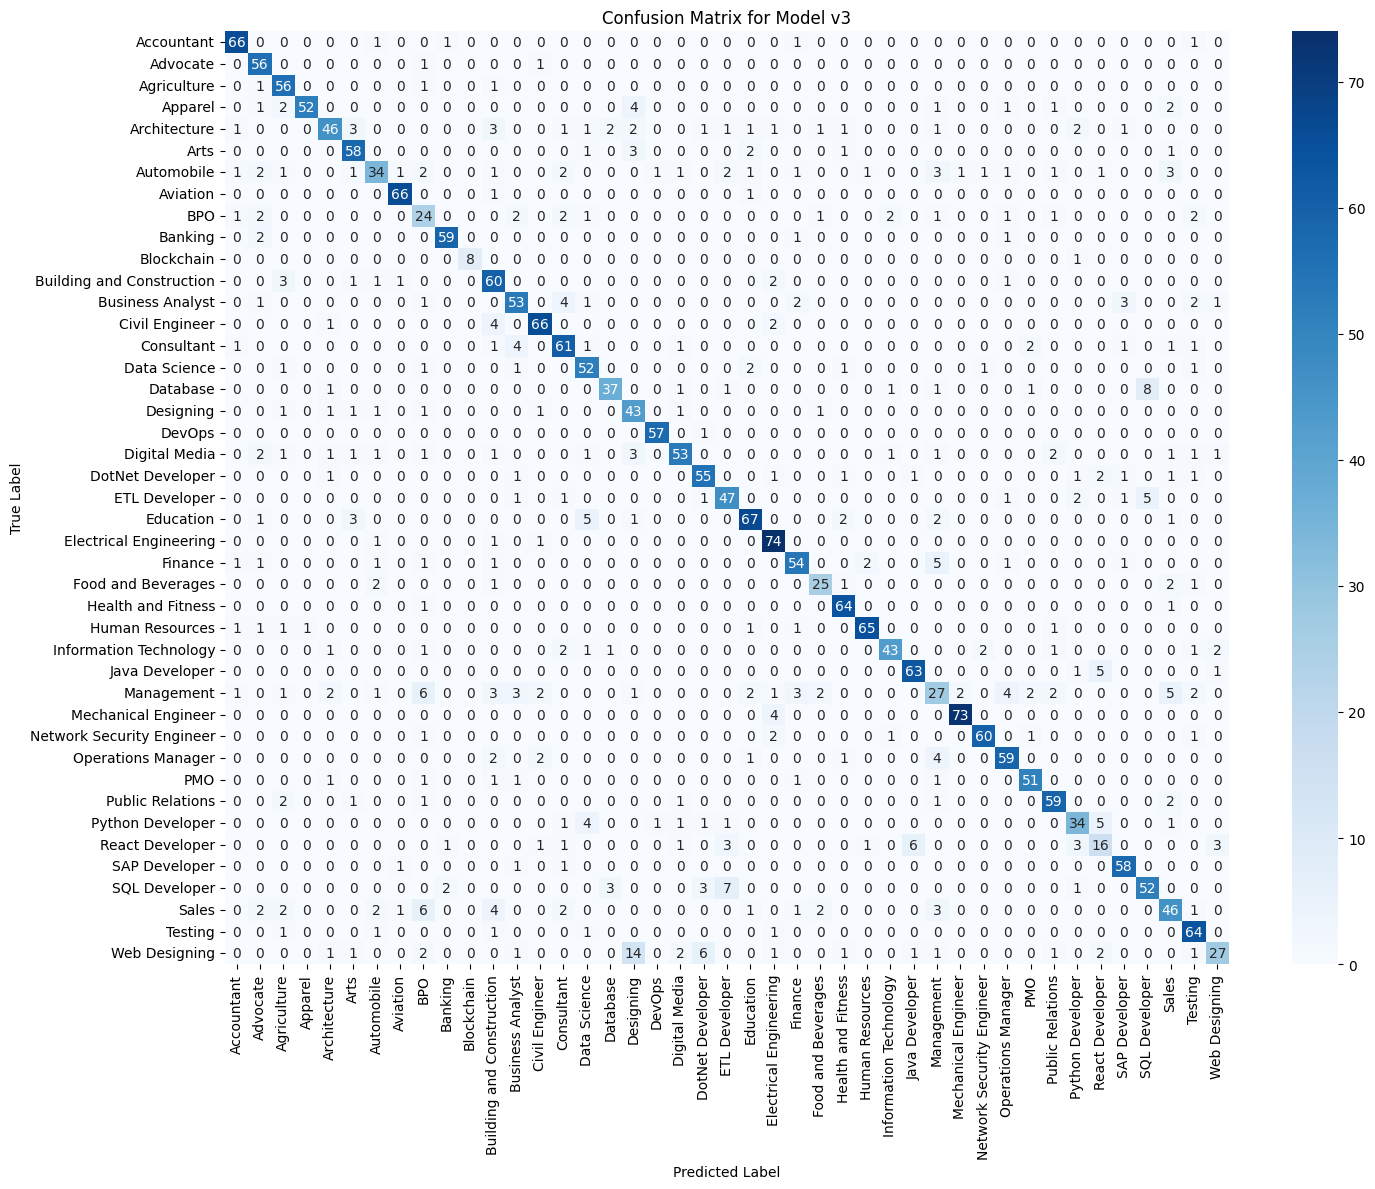

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(cm_v3, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Model v3')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

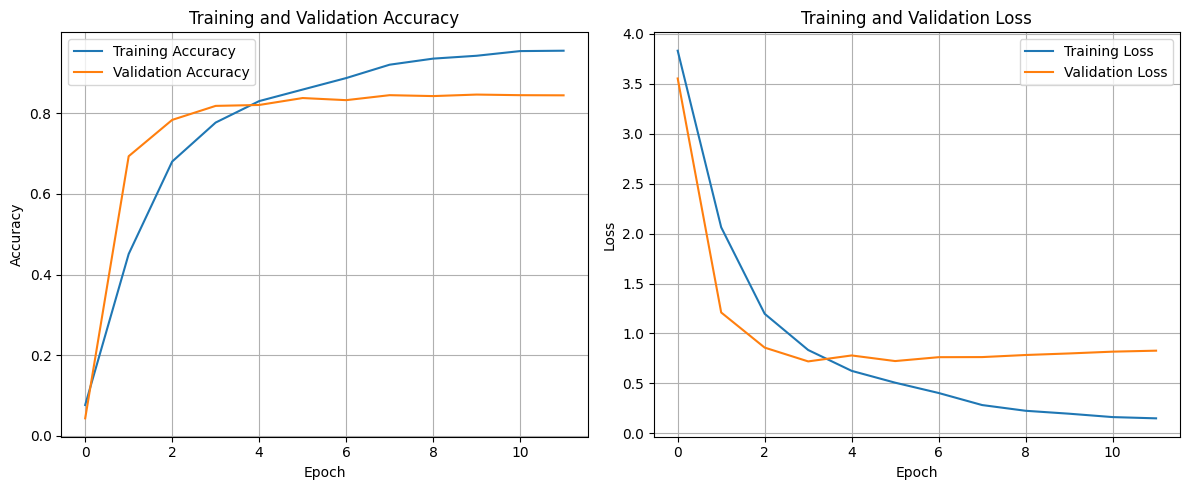

In [ ]:
import matplotlib.pyplot as plt

# Plotting accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v3.history['accuracy'], label='Training Accuracy')
plt.plot(history_v3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history_v3.history['loss'], label='Training Loss')
plt.plot(history_v3.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Test with a Python Developer resume text ---")
python_developer_resume = """
    Python Developer with 5 years experience in Django and Flask framework.
    Proficient in RESTful API development, database integration (PostgreSQL, MongoDB).
    Experienced with unit testing, CI/CD pipelines, and cloud platforms like AWS.
    Strong analytical skills and problem-solving abilities.
    """
predict_resume_v3(python_developer_resume)


--- Test with a Python Developer resume text ---
RESUME PREDICTION (v3 — Attention Model, 2-pass inference)
#1  Python Developer               100.0%  █████████████████████████████████ ← PREDICTION
#2  Data Science                     0.0%  
#3  Testing                          0.0%  


'Python Developer'

In [ ]:
print("\n--- Test with a Data Science resume text ---")
data_science_resume = """
    Data Scientist with expertise in machine learning, statistical modeling, and predictive analytics.
    Skilled in Python (Pandas, NumPy, Scikit-learn, TensorFlow, PyTorch) and R.
    Experience with data visualization (Matplotlib, Seaborn) and big data technologies (Spark, Hadoop).
    Developed and deployed several end-to-end machine learning solutions.
    """
predict_resume_v3(data_science_resume)


--- Test with a Data Science resume text ---
RESUME PREDICTION (v3 — Attention Model, 2-pass inference)
#1  Data Science                    98.9%  ████████████████████████████████ ← PREDICTION
#2  Python Developer                 1.1%  
#3  Testing                          0.0%  


'Data Science'

In [ ]:
import os
import pickle

# Create the directory if it doesn't exist
output_dir = "streamlit_assets"
os.makedirs(output_dir, exist_ok=True)

# 1. Save the Keras model in H5 format
model_path = os.path.join(output_dir, "resume_classifier.h5")
model_v3.save(model_path)
print(f"Model saved to: {model_path}")

# 2. Save the LabelEncoder
le_path = os.path.join(output_dir, "label_encoder.pkl")
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f"LabelEncoder saved to: {le_path}")

# 3. Save the Tokenizer
tokenizer_path = os.path.join(output_dir, "tokenizer.pkl")
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer_v3, f)
print(f"okenizer saved to: {tokenizer_path}")

Model saved to: streamlit_assets/resume_classifier.h5
LabelEncoder saved to: streamlit_assets/label_encoder.pkl
okenizer saved to: streamlit_assets/tokenizer.pkl
